In [1]:
import tensorflow as tf

DATA_DIR = "dataset/ML_Dataset/Dataset_train"
IMG_SIZE = (224, 224)   # standard size for pretrained models like MobileNet/ResNet
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"       # CIS vs non-CIS = binary classification
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print(class_names)   # should print ['CIS_train', 'non_CIS_train'] — check index order (0/1)

# Performance: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Normalize pixel values (0-255 -> 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 1766 files belonging to 2 classes.
Using 1413 files for training.
Found 1766 files belonging to 2 classes.
Using 353 files for validation.
['CIS_train', 'non_CIS_train']


In [2]:
from tensorflow.keras import layers, models

# Data augmentation (helps a small custom model generalize better)
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

custom_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary output: CIS vs non-CIS
])

custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

custom_model.save("custom_model.h5")

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5124 - loss: 0.7032 - val_accuracy: 0.5779 - val_loss: 0.6909
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 753ms/step - accuracy: 0.5173 - loss: 0.6930 - val_accuracy: 0.4334 - val_loss: 0.6955
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 719ms/step - accuracy: 0.5322 - loss: 0.6905 - val_accuracy: 0.5977 - val_loss: 0.6571
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 710ms/step - accuracy: 0.6058 - loss: 0.6666 - val_accuracy: 0.6119 - val_loss: 0.6576
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 717ms/step - accuracy: 0.6058 - loss: 0.6634 - val_accuracy: 0.6119 - val_loss: 0.6543
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 734ms/step - accuracy: 0.5980 - loss: 0.6537 - val_accuracy: 0.6091 - val_loss: 0.6463
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 762ms/step - accuracy: 0.6384 - loss: 0.6387 - val_accuracy: 0.6629 - val_loss: 0.6473
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 735ms/step - accuracy: 0.6313 - loss: 0.6396 - val_accurac

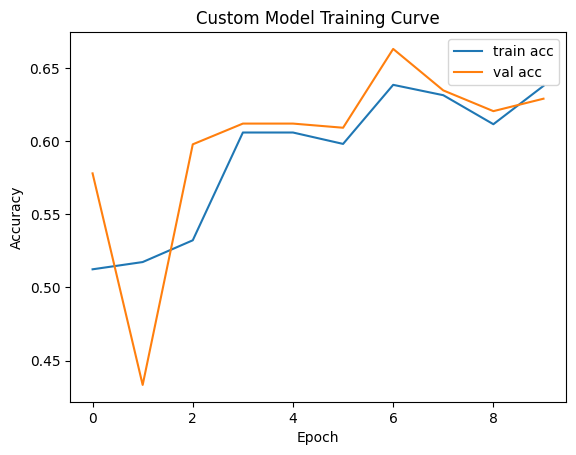

In [4]:
import matplotlib.pyplot as plt

plt.plot(history_custom.history['accuracy'], label='train acc')
plt.plot(history_custom.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Custom Model Training Curve')
plt.savefig('custom_model_curve.png')
plt.show()

In [5]:
final_train_acc = history_custom.history['accuracy'][-1]
final_val_acc = history_custom.history['val_accuracy'][-1]
best_val_acc = max(history_custom.history['val_accuracy'])
print(f"Final train acc: {final_train_acc:.4f}")
print(f"Final val acc: {final_val_acc:.4f}")
print(f"Best val acc: {best_val_acc:.4f}")

Final train acc: 0.6377
Final val acc: 0.6289
Best val acc: 0.6629


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze base for this baseline version

pretrained_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

pretrained_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

pretrained_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history_pretrained = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

pretrained_model.save("pretrained_v1_frozen.h5")

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 589ms/step - accuracy: 0.7396 - loss: 0.5293 - val_accuracy: 0.8527 - val_loss: 0.3682
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 566ms/step - accuracy: 0.8698 - loss: 0.3198 - val_accuracy: 0.8499 - val_loss: 0.3251
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 565ms/step - accuracy: 0.8988 - loss: 0.2543 - val_accuracy: 0.8782 - val_loss: 0.2843
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 571ms/step - accuracy: 0.9045 - loss: 0.2261 - val_accuracy: 0.8895 - val_loss: 0.2654
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 576ms/step - accuracy: 0.9243 - loss: 0.1997 - val_accuracy: 0.8697 - val_loss: 0.2829
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 661ms/step - accuracy: 0.9377 - loss: 0.1661 - val_accuracy: 0.9093 - val_loss: 0.2258
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 746ms/step - accuracy: 0.9363 - loss: 0.1701 - val_accuracy: 0.9178 - val_loss: 0.2133
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 659ms/step - accuracy: 0.9547 - loss: 0.1231 - val_accu

In [8]:
base_model2 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model2.trainable = True

# Freeze all layers except the last 30 — lets the model adapt higher-level features
for layer in base_model2.layers[:-30]:
    layer.trainable = False

pretrained_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

pretrained_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR since we're fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_v2 = pretrained_v2.fit(train_ds, validation_data=val_ds, epochs=10)
pretrained_v2.save("pretrained_v2_finetuned.h5")

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 738ms/step - accuracy: 0.5499 - loss: 0.7153 - val_accuracy: 0.5297 - val_loss: 0.7072
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 726ms/step - accuracy: 0.6702 - loss: 0.6082 - val_accuracy: 0.5977 - val_loss: 0.6602
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 736ms/step - accuracy: 0.7594 - loss: 0.5260 - val_accuracy: 0.6346 - val_loss: 0.6176
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 720ms/step - accuracy: 0.8209 - loss: 0.4615 - val_accuracy: 0.6884 - val_loss: 0.5799
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 718ms/step - accuracy: 0.8570 - loss: 0.4155 - val_accuracy: 0.7309 - val_loss: 0.5452
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 924ms/step - accuracy: 0.8903 - loss: 0.3584 - val_accuracy: 0.7592 - val_loss: 0.5097
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 756ms/step - accuracy: 0.9009 - loss: 0.3238 - val_accuracy: 0.7790 - val_loss: 0.4763
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 713ms/step - accuracy: 0.9200 - loss: 0.2876 - val_accu

In [9]:
base_model3 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model3.trainable = False

pretrained_v3 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,          # reuse the same augmentation layer from your custom model
    base_model3,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),        # higher dropout than v1's 0.3
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

pretrained_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_v3 = pretrained_v3.fit(train_ds, validation_data=val_ds, epochs=10)
pretrained_v3.save("pretrained_v3_augmented.h5")

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 665ms/step - accuracy: 0.6561 - loss: 0.6348 - val_accuracy: 0.7224 - val_loss: 0.5411
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 649ms/step - accuracy: 0.7757 - loss: 0.4847 - val_accuracy: 0.7960 - val_loss: 0.4384
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 644ms/step - accuracy: 0.7728 - loss: 0.4660 - val_accuracy: 0.7705 - val_loss: 0.4578
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 758ms/step - accuracy: 0.8033 - loss: 0.4348 - val_accuracy: 0.7989 - val_loss: 0.4092
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 654ms/step - accuracy: 0.8117 - loss: 0.4092 - val_accuracy: 0.7989 - val_loss: 0.4399
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 634ms/step - accuracy: 0.8167 - loss: 0.3904 - val_accuracy: 0.7960 - val_loss: 0.4163
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 632ms/step - accuracy: 0.8096 - loss: 0.4073 - val_accuracy: 0.8159 - val_loss: 0.3911
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 635ms/step - accuracy: 0.8188 - loss: 0.3811 - val_accu

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Use val_ds as your test set if you don't have a separate held-out test folder
test_ds = val_ds

models_dict = {
    "Custom CNN": custom_model,
    "Pretrained V1 (frozen)": pretrained_model,
    "Pretrained V2 (fine-tuned)": pretrained_v2,
    "Pretrained V3 (augmented)": pretrained_v3,
}

results = {}

for name, model in models_dict.items():
    y_true = []
    y_pred = []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_true.extend(labels.numpy().astype(int).flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    results[name] = {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
        "confusion_matrix": cm
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy: {report['accuracy']:.4f} | Precision: {report['weighted avg']['precision']:.4f} | "
          f"Recall: {report['weighted avg']['recall']:.4f} | F1: {report['weighted avg']['f1-score']:.4f}")
    print("Confusion Matrix:")
    print(cm)


=== Custom CNN ===
Accuracy: 0.6289 | Precision: 0.6236 | Recall: 0.6289 | F1: 0.6206
Confusion Matrix:
[[ 71  82]
 [ 49 151]]

=== Pretrained V1 (frozen) ===
Accuracy: 0.9207 | Precision: 0.9226 | Recall: 0.9207 | F1: 0.9201
Confusion Matrix:
[[132  21]
 [  7 193]]

=== Pretrained V2 (fine-tuned) ===
Accuracy: 0.8385 | Precision: 0.8384 | Recall: 0.8385 | F1: 0.8385
Confusion Matrix:
[[124  29]
 [ 28 172]]

=== Pretrained V3 (augmented) ===
Accuracy: 0.8414 | Precision: 0.8420 | Recall: 0.8414 | F1: 0.8416
Confusion Matrix:
[[127  26]
 [ 30 170]]


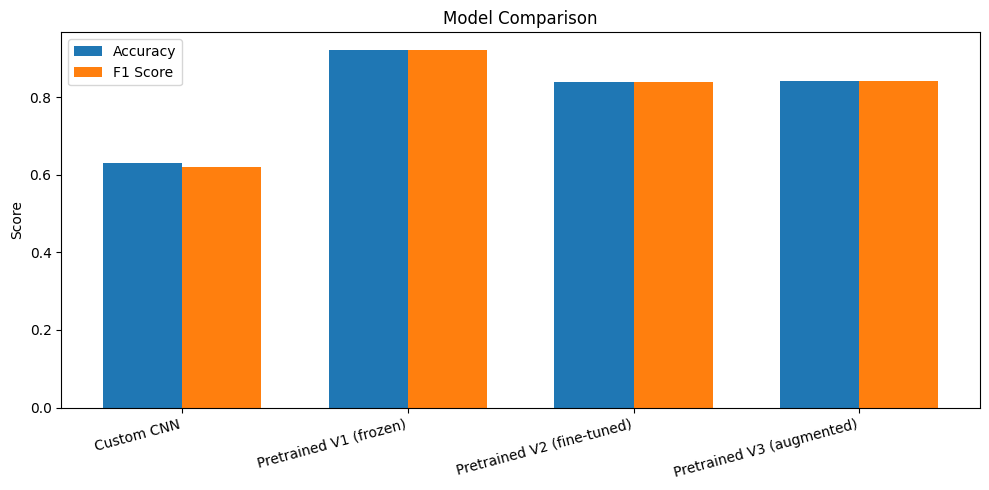

In [11]:
import matplotlib.pyplot as plt

names = list(results.keys())
accs = [results[n]["accuracy"] for n in names]
f1s = [results[n]["f1"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, accs, width, label='Accuracy')
ax.bar(x + width/2, f1s, width, label='F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()